In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import optuna
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)

In [60]:
df = pd.read_csv("../dataset/student.csv")
print(f"Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded successfully: 1044 rows, 33 columns


In [61]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [62]:
for col in ["Mjob", "Fjob", "reason", "guardian"]:
    dummies = pd.get_dummies(df[col], prefix=col)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[col], inplace=True)

df = df.drop(columns=["school", "address"])

df["sex_male"] = df["sex"] == "M"
df["parent_together"] = df["Pstatus"] == "T"
df["famsize_large"] = df["famsize"] == "GT3"

mapping = {1: 60, 2: 210, 3: 450, 4: 720}
df["traveltime_minutes"] = df["traveltime"].map(mapping)
df["studytime_minutes"] = df["studytime"].map(mapping)

for col in ["schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]:
    df[col] = (df[col] == "yes").astype(int)

for col in ["G1", "G2", "G3"]:
    df[col] = df[col] * 5

df["avg_parent_edu"] = (df["Medu"] + df["Fedu"]) / 2
df["total_support"] = df[["schoolsup", "famsup", "paid"]].sum(axis=1)
df["study_per_travel"] = df["studytime_minutes"] / (df["traveltime_minutes"] + 1)

df = df.drop(columns=["schoolsup", "Pstatus", "famsup", "paid", "studytime_minutes", "traveltime_minutes", "studytime", "Medu", "Fedu", "sex", "famsize"])

In [63]:
df.head()

,age,traveltime,failures,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,Mjob_at_home,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_at_home,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other,sex_male,parent_together,famsize_large,avg_parent_edu,total_support,study_per_travel
0,18,2,0,0,1,1,0,0,4,3,4,1,1,3,6,25,30,30,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,False,True,4.0,1,0.995261
1,17,1,0,0,0,1,1,0,5,3,3,1,1,3,4,25,25,30,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,True,True,1.0,1,3.442623
2,15,1,3,0,1,1,1,0,4,3,2,2,3,3,10,35,40,50,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,1.0,2,3.442623
3,15,1,0,1,1,1,1,1,3,2,2,1,1,5,2,75,70,75,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,True,True,3.0,2,7.377049
4,16,1,0,0,1,1,0,0,4,3,2,1,2,5,4,30,50,50,False,False,True,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,True,True,3.0,2,3.442623


In [64]:
X = df.drop(columns=["G3"]).select_dtypes(include=[np.number])
y = df["G3"]

selector = SelectFromModel(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1), 
    threshold="median"
)
selector.fit(X, y)
X_selected = selector.transform(X)
print(f"Selected {X_selected.shape[1]} features from {X.shape[1]} total features")

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

Selected 10 features from 20 total features


In [65]:
# Optuna tuning for RandomForestRegressor
import optuna
import os
from contextlib import redirect_stdout


def rf_objective(trial: optuna.trial.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 4, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 8),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42,
        "n_jobs": -1,
    }
    model = RandomForestRegressor(**params)
    score = -cross_val_score(model, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1).mean()
    return score


rf_study = optuna.create_study(direction="minimize")
with open(os.devnull, 'w') as devnull, redirect_stdout(devnull):
    rf_study.optimize(rf_objective, n_trials=40, show_progress_bar=True)

rf_best_params = rf_study.best_params
rf_best_params.update({"random_state": 42, "n_jobs": -1})
rf_optuna_model = RandomForestRegressor(**rf_best_params)
rf_optuna_model.fit(X_train, y_train)

rf_pred_test = rf_optuna_model.predict(X_test)
rf_pred_train = rf_optuna_model.predict(X_train)

rf_rmse = mean_squared_error(y_test, rf_pred_test) ** 0.5
rf_mae = mean_absolute_error(y_test, rf_pred_test)
rf_r2 = r2_score(y_test, rf_pred_test)
rf_train_r2 = r2_score(y_train, rf_pred_train)
rf_generalization_gap = rf_train_r2 - rf_r2

print("RF Best params (Optuna):", rf_best_params)
print("RF Test RMSE:", rf_rmse)
print("RF Test R^2:", rf_r2)
print("RF Test MAE:", rf_mae)
print("RF Train R^2:", rf_train_r2)
print("RF generalization gap:", rf_generalization_gap)

[I 2026-04-01 15:35:41,333] A new study created in memory with name: no-name-7f6960d6-9e2b-47e3-a51d-6cf8f5624ab4


  0%|          | 0/40 [00:00<?, ?it/s]

RF Best params (Optuna): {'n_estimators': 516, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': None, 'random_state': 42, 'n_jobs': -1}
RF Test RMSE: 8.07092390548757
RF Test R^2: 0.8314712408472136
RF Test MAE: 4.487967905289
RF Train R^2: 0.9007570669307857
RF generalization gap: 0.06928582608357214


In [66]:
# Optuna tuning for XGBRegressor
import optuna
import os
from contextlib import redirect_stdout


def xgb_objective(trial: optuna.trial.Trial) -> float:
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 700),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.5, 10.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "verbosity": 0,
        "n_jobs": -1,
    }
    model = XGBRegressor(**params)
    score = -cross_val_score(model, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1).mean()
    return score


xgb_study = optuna.create_study(direction="minimize")
with open(os.devnull, 'w') as devnull, redirect_stdout(devnull):
    xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

xgb_best_params = xgb_study.best_params
xgb_best_params.update({
    "random_state": 42,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "verbosity": 0,
    "n_jobs": -1,
})

xgb_optuna_model = XGBRegressor(**xgb_best_params)
xgb_optuna_model.fit(X_train, y_train)

xgb_pred_test = xgb_optuna_model.predict(X_test)
xgb_pred_train = xgb_optuna_model.predict(X_train)

xgb_rmse = mean_squared_error(y_test, xgb_pred_test) ** 0.5
xgb_mae = mean_absolute_error(y_test, xgb_pred_test)
xgb_r2 = r2_score(y_test, xgb_pred_test)
xgb_train_r2 = r2_score(y_train, xgb_pred_train)
xgb_generalization_gap = xgb_train_r2 - xgb_r2

print("XGB Best params (Optuna):", xgb_best_params)
print("XGB Test RMSE:", xgb_rmse)
print("XGB Test R^2:", xgb_r2)
print("XGB Test MAE:", xgb_mae)
print("XGB Train R^2:", xgb_train_r2)
print("XGB generalization gap:", xgb_generalization_gap)

[I 2026-04-01 15:36:19,981] A new study created in memory with name: no-name-1925c078-21b4-43f5-b534-4d67c18131e2


  0%|          | 0/50 [00:00<?, ?it/s]

XGB Best params (Optuna): {'n_estimators': 239, 'learning_rate': 0.01834187539920762, 'max_depth': 5, 'min_child_weight': 8.074118237557919, 'subsample': 0.5592215864316263, 'colsample_bytree': 0.8500063162692698, 'gamma': 0.019131948920351624, 'reg_alpha': 0.0008469913363823815, 'reg_lambda': 0.3597808390003683, 'random_state': 42, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'verbosity': 0, 'n_jobs': -1}
XGB Test RMSE: 8.060051124732446
XGB Test R^2: 0.8319249749183655
XGB Test MAE: 4.710592746734619
XGB Train R^2: 0.9272027611732483
XGB generalization gap: 0.09527778625488281


In [67]:
print("\n===================== MODEL COMPARISON =====================")
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE': [rf_rmse, xgb_rmse],
    'R²': [rf_r2, xgb_r2],
    'MAE': [rf_mae, xgb_mae]
})

print(comparison.to_string(index=False))
best_model = 'XGBoost' if xgb_r2 > rf_r2 else 'Random Forest'
print(f"\nBest model: {best_model}")


===================== MODEL COMPARISON =====================
        Model     RMSE       R²      MAE
Random Forest 8.070924 0.831471 4.487968
      XGBoost 8.060051 0.831925 4.710593

Best model: XGBoost


In [68]:
# Select the best model based on R² (highest is best)
best_model_r2 = max(rf_r2, xgb_r2)
if rf_r2 > xgb_r2:
    best_estimator = rf_optuna_model
    best_predictions = rf_pred_test
    best_model_name = 'Random Forest (Optuna)'
    best_model_rmse = rf_rmse
    best_model_mae = rf_mae
    is_rf = True
else:
    best_estimator = xgb_optuna_model
    best_predictions = xgb_pred_test
    best_model_name = 'XGBoost (Optuna)'
    best_model_rmse = xgb_rmse
    best_model_mae = xgb_mae
    is_rf = False

print(f"\nBEST MODEL: {best_model_name}")
print(f"   RMSE: {best_model_rmse:.4f}")
print(f"   R²: {best_model_r2:.4f}")
print(f"   MAE: {best_model_mae:.4f}")
print(f"   Type: {'Random Forest' if is_rf else 'XGBoost'}")


BEST MODEL: XGBoost (Optuna)
   RMSE: 8.0601
   R²: 0.8319
   MAE: 4.7106
   Type: XGBoost


Top features by average SHAP impact:


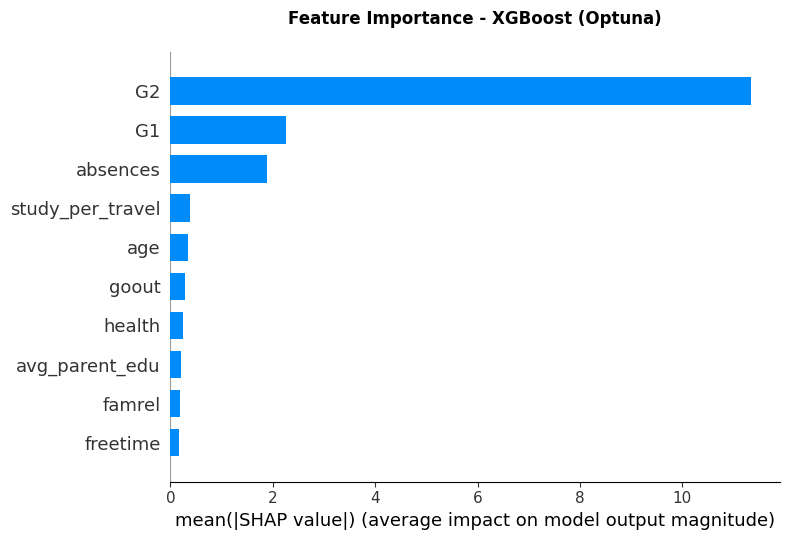


Feature impact on predictions:


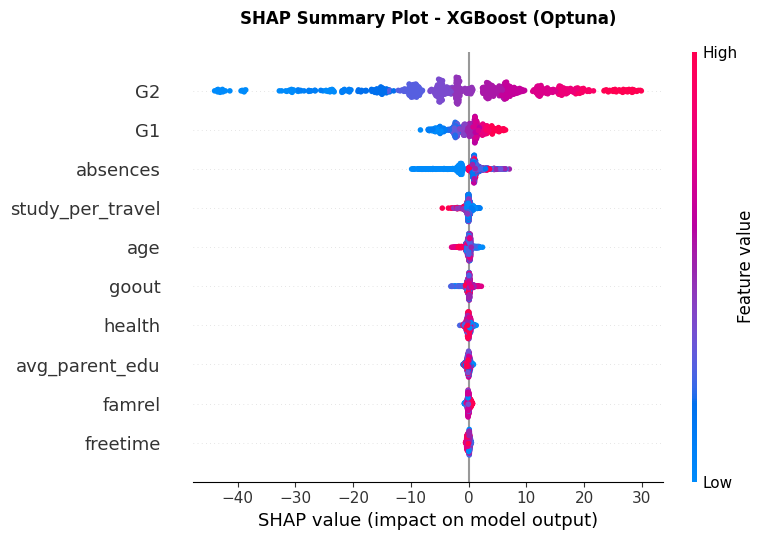

In [69]:
# Get feature names
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
X_train_df = pd.DataFrame(X_train, columns=selected_features)
X_test_df = pd.DataFrame(X_test, columns=selected_features)

# Create explainer based on model type
if is_rf:
    explainer_best = shap.TreeExplainer(best_estimator)
    shap_values_best = explainer_best.shap_values(X_train_df)
    expected_value = explainer_best.expected_value
else:
    # For XGBoost
    explainer_best = shap.TreeExplainer(best_estimator)
    shap_values_best = explainer_best.shap_values(X_train_df)
    expected_value = explainer_best.expected_value

# Summary plot - Feature importance
print("Top features by average SHAP impact:")
shap.summary_plot(shap_values_best, X_train_df, plot_type="bar", show=False)
plt.title(f"Feature Importance - {best_model_name}", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nFeature impact on predictions:")
shap.summary_plot(shap_values_best, X_train_df, show=False)
plt.title(f"SHAP Summary Plot - {best_model_name}", fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Explaining predictions from XGBoost (Optuna)...

Sample Predictions (first 5):
Actual    Predicted   Error     
--------------------------------
55.00     50.49       4.51      
40.00     42.08       2.08      
65.00     64.83       0.17      
55.00     55.91       0.91      
60.00     63.92       3.92      


SHAP Force Plot - Sample #1:
Actual value: 55.00
Predicted value: 51.81
(Base value = model's average prediction. Red = increases prediction, Blue = decreases)



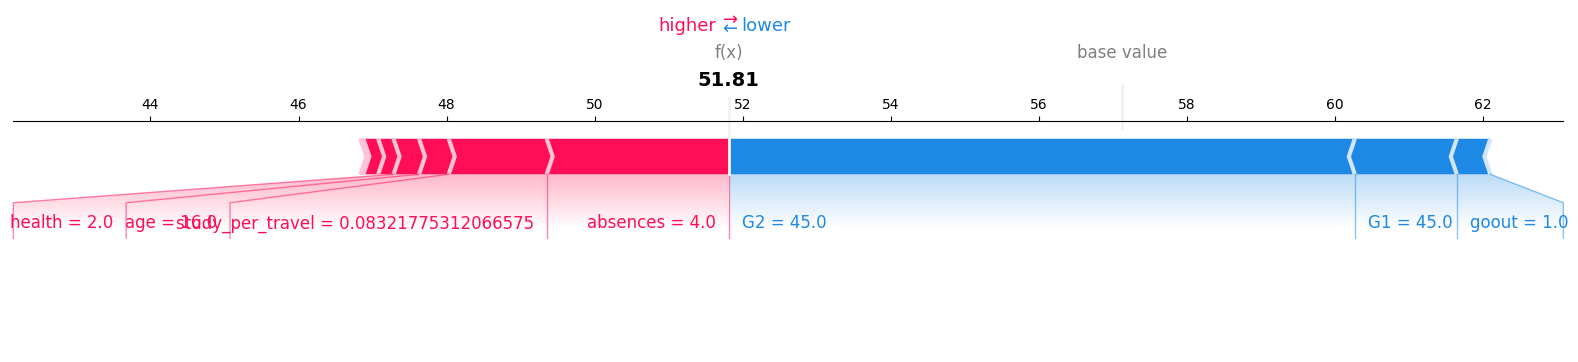

<Figure size 640x480 with 0 Axes>



Top Contributing Factors for Sample #1:
------------------------------------------------------------
 1. G2                        ↓ decreases     (-8.4596)
 2. absences                  ↑ increases     (+2.4585)
 3. G1                        ↓ decreases     (-1.3779)
 4. study_per_travel          ↑ increases     (+1.3233)
 5. goout                     ↓ decreases     (-0.4538)
 6. age                       ↑ increases     (+0.4008)
 7. health                    ↑ increases     (+0.3446)
 8. freetime                  ↑ increases     (+0.2072)
 9. avg_parent_edu            ↑ increases     (+0.1997)
10. famrel                    ↑ increases     (+0.0399)


In [70]:
print(f"Explaining predictions from {best_model_name}...\n")

# Show predictions vs actual for a few samples
print("Sample Predictions (first 5):")
print(f"{'Actual':<10}{'Predicted':<12}{'Error':<10}")
print("-" * 32)
for i in range(min(5, len(y_test))):
    actual = y_test.iloc[i]
    pred = best_predictions[i]
    error = abs(actual - pred)
    print(f"{actual:<10.2f}{pred:<12.2f}{error:<10.2f}")

# SHAP force plot for first sample
print(f"\n\nSHAP Force Plot - Sample #1:")
print(f"Actual value: {y_train.iloc[0]:.2f}")
print(f"Predicted value: {best_estimator.predict(X_train_df.iloc[0:1])[0]:.2f}")
print("(Base value = model's average prediction. Red = increases prediction, Blue = decreases)\n")

shap.force_plot(
    expected_value,
    shap_values_best[0],
    X_train_df.iloc[0],
    matplotlib=True
)
plt.tight_layout()
plt.show()

# Detailed explanation
def explain_prediction_detailed(shap_vals, features, threshold=0.01):
    """Generate human-readable explanation of prediction contributions."""
    contributions = []
    for i, feat in enumerate(features):
        if abs(shap_vals[i]) > threshold:
            impact = "↑ increases" if shap_vals[i] > 0 else "↓ decreases"
            contributions.append((feat, shap_vals[i], impact))
    
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    return contributions

print("\n\nTop Contributing Factors for Sample #1:")
print("-" * 60)
contributions = explain_prediction_detailed(shap_values_best[0], selected_features)
for i, (feat, impact_val, direction) in enumerate(contributions[:10], 1):
    print(f"{i:2}. {feat:<25} {direction:<15} ({impact_val:+.4f})")